# Измерение высоты золотых наночастиц AFM
One-pass, end-to-end workflow for Bruker/Veeco Nanoscope `.001` files.

**Author:** _your name_  **Date:** _YYYY-MM-DD_

**Table of contents**
1. [Шаг 1 — Загрузка файлов Nanoscope .001](#step-1--loading-nanoscope-001-files)
2. [Шаг 2 — Предобработка](#step-2--preprocessing)
3. [Шаг 3 — Карта подложки](#step-3--substrate-map)
4. [Шаг 4 — Детекция частиц (LoG)](#step-4--particle-detection-log)
5. [Шаг 5 — Измерение высоты и локальный baseline](#step-5--height-measurement--local-baseline)
6. [Шаг 6 — Алгоритм baseline (круговые маски)](#step-6--baseline-algorithm-circular-masks)
7. [Шаг 7 — Сегментация SAM 2](#step-7--sam-2-segmentation)
8. [Шаг 8 — Результаты и сравнение](#step-8--results--comparison)
9. [Руководство по настройке параметров](#parameter-tuning-guide)


## Проверка перед запуском

Cells in order (one-line each):
1. Title and table of contents
2. Preflight checklist (this cell)
3. Installation commands (commented)
4. Imports and version checks
5. Configuration (CFG)
6. Step 1 markdown (file format)
7. Step 1 code (loader + synthetic data + preview)
8. Step 2 markdown (preprocessing)
9. Step 2 code (plane + line flattening)
10. Step 3 markdown (substrate)
11. Step 3 code (morphological opening)
12. Step 4 markdown (LoG detection)
13. Step 4 code (blob detection + overlay)
14. Step 5 markdown (height measurement)
15. Step 5 code (mask + ring + measurement functions)
16. Step 6 markdown (baseline algorithm)
17. Step 6 code (baseline measurements)
18. Step 7 markdown (SAM 2)
19. Step 7 code (SAM 2 segmentation)
20. Step 8 markdown (results)
21. Step 8 code (visualizations)
22. Statistics & comparison code
23. Export code (CSV)
24. Parameter tuning guide

Pixel size flow:
- `pixel_size_nm` is computed in the loader or synthetic generator (Step 1 code).
- It is used to convert LoG sigma to physical radius in Step 4.
- It is used to compute `x_nm`, `y_nm` in the export cell.

End-to-end check:
- The notebook runs top-to-bottom with `use_synthetic=True`.
- If `SAM_AVAILABLE=False`, the SAM cells skip gracefully and continue.


In [1]:
# Базовые пакеты
# !pip install numpy scipy scikit-image matplotlib pandas tqdm

# Чтение AFM-файлов (пробовать по порядку)
# !pip install pySPM
# !pip install git+https://github.com/jmarini/nanoscope

# Сегментация SAM 2 (опционально)
# !pip install git+https://github.com/facebookresearch/sam2.git
# Скачать чекпоинт:
# !wget https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_base_plus.pt


In [2]:
# Базовые импорты с надежными резервными вариантами
try:
    import numpy as np
except Exception as e:
    raise ImportError("Missing numpy. Install with: pip install numpy") from e

try:
    import pandas as pd
except Exception as e:
    raise ImportError("Missing pandas. Install with: pip install pandas") from e

try:
    import matplotlib.pyplot as plt
except Exception as e:
    raise ImportError("Missing matplotlib. Install with: pip install matplotlib") from e

try:
    import scipy as sp
    from scipy import ndimage as ndi
    from scipy import linalg
    from scipy.spatial import cKDTree
    from scipy.stats import pearsonr
except Exception as e:
    raise ImportError("Missing scipy. Install with: pip install scipy") from e

try:
    import skimage as sk
    from skimage.feature import blob_log
    from skimage.morphology import disk, opening
    from skimage.exposure import rescale_intensity
except Exception as e:
    raise ImportError("Missing scikit-image. Install with: pip install scikit-image") from e

try:
    import tqdm as tqdm_mod
    from tqdm import tqdm
except Exception as e:
    raise ImportError("Missing tqdm. Install with: pip install tqdm") from e

# Импорты из src — единый источник обработки
from src.config import default_cfg
from src.preprocess import flatten_plane, flatten_lines, get_substrate_map
from src.detection import detect_seeds
from src.measure import create_circular_mask, measure_height
from src.sam2_pipeline import afm_to_rgb

# Опциональный импорт SAM 2
SAM_AVAILABLE = False
try:
    from sam2.build_sam import build_sam2
    from sam2.sam2_image_predictor import SAM2ImagePredictor
    SAM_AVAILABLE = True
except Exception:
    SAM_AVAILABLE = False

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("scipy:", sp.__version__)
print("skimage:", sk.__version__)
print("tqdm:", tqdm_mod.__version__)
print("SAM 2 available:", SAM_AVAILABLE)


import re
from pathlib import Path
from datetime import datetime
from typing import Dict, Tuple, Any, Optional, List


# Опциональные ридеры Nanoscope
HAS_NANOSCOPE = False
try:
    import nanoscope as ns_mod
    HAS_NANOSCOPE = True
except Exception:
    ns_mod = None
    HAS_NANOSCOPE = False

HAS_PYSPM = False
try:
    import pySPM as pyspm_mod
    HAS_PYSPM = True
except Exception:
    pyspm_mod = None
    HAS_PYSPM = False


numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8
scipy: 1.17.1
skimage: 0.26.0
tqdm: 4.67.3
SAM 2 available: True


In [3]:
# ⚙️ КОНФИГУРАЦИЯ
CFG = default_cfg()
CFG.update({
    # ── ФАЙЛ ──────────────────────────────
    'file_path':   'data/2025/11 Febraury/si-dbs-au-3.007',  # путь к файлу Nanoscope .001
    'use_synthetic': False,            # True = сгенерировать тестовые данные, реальный файл не нужен

    # ── РАЗМЕР ЧАСТИЦ (нм) ────────────────
    'particle_min_nm': 5,
    'particle_max_nm': 20,

    # ── ЧУВСТВИТЕЛЬНОСТЬ ДЕТЕКЦИИ ─────────────
    'log_threshold': 0.05,            # меньше = будет найдено больше частиц (0.01–0.2)
    'log_overlap':   0.3,

    # ── ОЦЕНКА ПОДЛОЖКИ ──────────────
    'opening_radius_px': 15,          # должно быть > радиуса крупнейшей частицы в пикселях

    # ── ИЗМЕРЕНИЕ ВЫСОТЫ ────────────────
    'min_height_nm':      0.5,        # отбрасывать всё ниже этого порога
    'ring_outer_px':      7,          # ширина кольца для локального baseline
    'ring_inner_erode_px': 2,

    # ── СОПОСТАВЛЕНИЕ ───────────────────────
    'match_radius_px': 10,

    # ── SAM 2 ─────────────────────────────
    'sam_checkpoint': 'sam2.1_hiera_base_plus.pt',
    'sam_config':     'sam2.1_hiera_b+.yaml',
    'device':         'cuda',         # 'cuda' или 'cpu'
    'colormap':       'afmhot',       # попробуйте: 'afmhot', 'viridis', 'gray'
    'clip_percentile': 99,
})

print("CFG loaded with file:", CFG['file_path'])


CFG loaded with file: data/2025/11 Febraury/si-dbs-au-3.007


## Визуализации для удобства

In [7]:
def plot_afm_height(
    z: np.ndarray,
    pixel_size_nm: float,
    title: str = "AFM height map",
    center_zero: bool = True,
    cmap: str = "afmhot",
    scalebar_nm: float | None = None,
):
    """
    Красивая научная визуализация AFM-карты высот.

    Parameters
    ----------
    z : np.ndarray
        Карта высот (нм)
    pixel_size_nm : float
        Размер пикселя (нм)
    title : str
        Заголовок
    center_zero : bool
        Центрировать цветовую шкалу по медиане
    cmap : str
        Цветовая карта
    scalebar_nm : float | None
        Длина масштабной линейки (нм). Если None — авто.
    """

    z = np.asarray(z, dtype=np.float32)

    # --- центрирование ---
    if center_zero:
        z_plot = z - np.median(z)
    else:
        z_plot = z

    zmin, zmax = float(z_plot.min()), float(z_plot.max())

    extent = [
        0,
        z.shape[1] * pixel_size_nm,
        z.shape[0] * pixel_size_nm,
        0,
    ]

    fig, ax = plt.subplots(figsize=(5.5, 5))

    im = ax.imshow(
        z_plot,
        cmap=cmap,
        extent=extent,
        interpolation="nearest",
    )

    ax.set_title(
        f"{title}\nrange {zmin:.2f} to {zmax:.2f} nm",
        fontsize=11,
    )
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("height (nm)")

    # --- масштабная линейка ---
    if scalebar_nm is None:
        width_nm = z.shape[1] * pixel_size_nm
        scalebar_nm = width_nm / 5

    x0 = extent[0] + 0.05 * (extent[1] - extent[0])
    y0 = extent[2] - 0.08 * (extent[2] - extent[3])

    ax.plot(
        [x0, x0 + scalebar_nm],
        [y0, y0],
        color="white",
        linewidth=3,
        solid_capstyle="butt",
    )

    ax.text(
        x0 + scalebar_nm / 2,
        y0 - 0.03 * (extent[2] - extent[3]),
        f"{scalebar_nm:.0f} nm",
        color="white",
        ha="center",
        va="top",
        fontsize=9,
    )

    plt.tight_layout()
    plt.show()

## Шаг 1 — Загрузка файлов Nanoscope .001

Файлы Nanoscope `.000` содержат ASCII-заголовок, за которым следует бинарная часть. Заголовок включает смещения, размеры в пикселях, размер сканирования и **масштаб Z (Z scale)**, который переводит сырые целые значения в нанометры.

Ключевые поля заголовка, которые мы извлекаем:

* `Data offset` и `Data length` (где начинается бинарные данные)

* `Samps/line` и `Number of lines`

* `Bytes/pixel` (обычно 2 или 4)

* `Scan size` (нм)

* строка `Z scale`: `V [Sens. Zscan] (X.XXX V/LSB) * XX.X nm/V`

Формула масштаба Z:

`(V/LSB) × (nm/V) = nm/LSB`

Умножьте целочисленные значения на `nm/LSB`, чтобы получить карту высот в нанометрах.


(512, 512) float32 -135.9952 2514.76


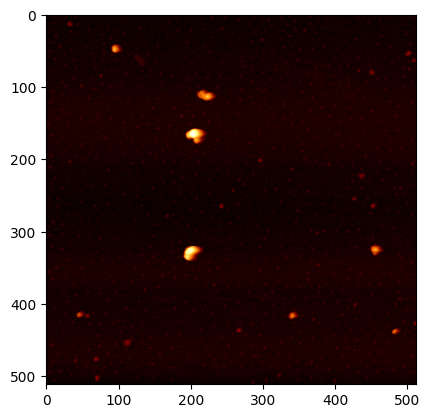

In [4]:
from src.afm_io import load_afm

z = load_afm('data/2025/18 February/5.009', fmt='spm')
print(z.shape, z.dtype, np.nanmin(z), np.nanmax(z))
plt.imshow(z, cmap='afmhot')

assert z.ndim == 2
assert isinstance(z, np.ndarray)

## Шаг 2 — Предобработка
AFM-изображения часто содержат **plane tilt | наклон плоскости** из-за неидеального выравнивания и **артефакты строк** от дрейфа сканера. Мы удаляем оба эффекта перед анализом:

- **Вычитание плоскости** — подгонка методом МНК плоскости к топологии.
- **Выравнивание строк** — подгонка полинома низкого порядка к каждой строке сканирования.


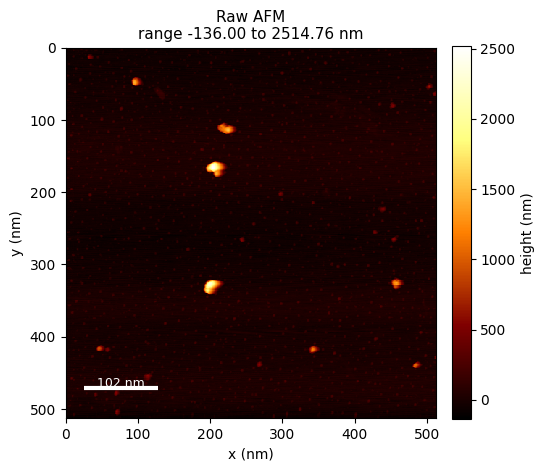

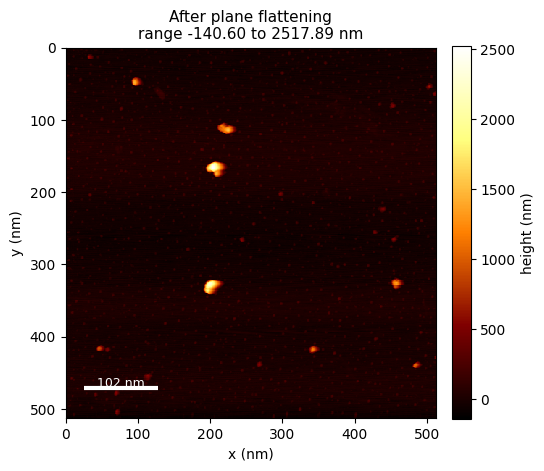

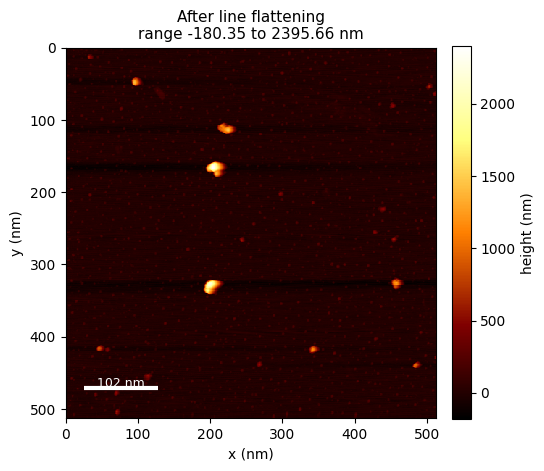

In [9]:
POLY_ORDER = 1
z_raw = z.copy()

z_plane = flatten_plane(z_raw)
z_flat = flatten_lines(z_plane, poly_order=POLY_ORDER)

plot_afm_height(z_raw, pixel_size_nm=1, title="Raw AFM", center_zero=False)
plot_afm_height(z_plane, pixel_size_nm=1, title="After plane flattening", center_zero=False)
plot_afm_height(z_flat, pixel_size_nm=1, title="After line flattening", center_zero=False)


## Шаг 3 — Карта подложки
A **morphological opening** with a disk larger than any particle slides under
particles and preserves only the slowly varying substrate. Subtracting this
substrate map isolates the particle heights.

Key parameter: `opening_radius_px` (must be larger than the largest particle radius).


In [ ]:
opening_radius_px = int(CFG['opening_radius_px'])
substrate = get_substrate_map(z_flat, opening_radius_px)
z_above = z_flat - substrate

if opening_radius_px < max(5, min(z_flat.shape) // 30):
    print("Warning: opening_radius_px may be too small for this image size.")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(z_flat, cmap='afmhot', extent=nm_extent(z_flat, pixel_size_nm))
axes[0].set_title("Flattened Z (nm)")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")
plt.colorbar(im0, ax=axes[0], label="height (nm)")

im1 = axes[1].imshow(substrate, cmap='afmhot', extent=nm_extent(substrate, pixel_size_nm))
axes[1].set_title(f"Substrate (radius {opening_radius_px} px)")
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("y (nm)")
plt.colorbar(im1, ax=axes[1], label="height (nm)")

im2 = axes[2].imshow(z_above, cmap='afmhot', extent=nm_extent(z_above, pixel_size_nm))
axes[2].set_title("Above-substrate Z (nm)")
axes[2].set_xlabel("x (nm)")
axes[2].set_ylabel("y (nm)")
plt.colorbar(im2, ax=axes[2], label="height (nm)")

plt.tight_layout()
plt.show()
print("Substrate estimation complete.")


## Шаг 4 — Детекция частиц (LoG)
We use **Laplacian-of-Gaussian (LoG)** blob detection to find particle centers.
LoG works across multiple scales (sigma values). The radius estimate is:

`radius_nm = sigma_px × √2 × pixel_size_nm`

This gives an approximate particle size for later masking.


In [ ]:
CFG['pixel_size_nm'] = float(pixel_size_nm)
blobs = detect_seeds(z_above, CFG)

if blobs.size == 0:
    print("No particles detected. Try lowering log_threshold.")
else:
    sigmas = blobs[:, 2]
    radii_nm = sigmas * np.sqrt(2) * pixel_size_nm
    diam_nm = 2.0 * radii_nm
    print(f"Detected {len(blobs)} candidates")
    print(f"Sigma range (px): {sigmas.min():.2f} to {sigmas.max():.2f}")
    print(f"Diameter range (nm): {diam_nm.min():.1f} to {diam_nm.max():.1f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(z_above, cmap='afmhot', extent=nm_extent(z_above, pixel_size_nm))
for y, x, s in blobs:
    r_nm = s * np.sqrt(2) * pixel_size_nm
    circ = plt.Circle((x * pixel_size_nm, y * pixel_size_nm), r_nm, color='cyan', fill=False, linewidth=1)
    ax.add_patch(circ)
ax.set_title(f"LoG detections (threshold={CFG['log_threshold']}, overlap={CFG['log_overlap']})")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
plt.show()
print("Detection complete.")


## Шаг 5 — Измерение высоты и локальный baseline
We measure height as:

`height = max(Z inside mask) − median(Z in annular ring)`

The annular ring (a donut around the particle) provides a **local baseline**,
which is more robust than a global median when the substrate varies.

```
   ring
  ______
 /      \
|  disk |
 \____/
```


In [ ]:
print("Measurement utilities ready.")


## Шаг 6 — Алгоритм baseline (круговые маски)
We use the LoG radius to build a **circular mask** for each particle and
measure height with the local ring baseline. This is fast and provides a
baseline reference for the more precise SAM 2 segmentation.


In [ ]:
records = []

ring_outer_px = int(CFG['ring_outer_px'])
ring_inner_erode_px = int(CFG['ring_inner_erode_px'])
min_height_nm = float(CFG['min_height_nm'])

for y, x, s in tqdm(blobs, desc="Measuring baseline"):
    radius_px = float(s * np.sqrt(2))
    mask = create_circular_mask(z_above.shape, y, x, radius_px)
    m = measure_height(z_above, mask, ring_outer_px, ring_inner_erode_px)
    if np.isfinite(m['height_nm']) and m['height_nm'] >= min_height_nm:
        records.append({
            "y_px": float(y),
            "x_px": float(x),
            "sigma_px": float(s),
            **m,
        })

df_baseline = pd.DataFrame.from_records(records)

print("Baseline measurements:")
print(df_baseline.describe().T)


## Шаг 7 — Сегментация SAM 2
LoG provides **where** the particle is; SAM 2 refines **what** the exact shape is.
We prompt SAM with a point at each LoG center and let it return a mask.

AFM maps are single-channel, so we convert them to RGB using a colormap.
The colormap can affect segmentation quality by enhancing contrast.


In [ ]:
class SAMSegmentor:
    """Simple wrapper around SAM 2 image predictor."""

    def __init__(self, checkpoint: str, config: str, device: str = 'cpu') -> None:
        self.checkpoint = checkpoint
        self.config = config
        self.device = device
        self.model = build_sam2(config, checkpoint, device=device)
        self.predictor = SAM2ImagePredictor(self.model)

    def encode(self, image_rgb: np.ndarray) -> None:
        """Encode image for segmentation.

        Parameters
        ----------
        image_rgb : np.ndarray
            RGB image.
        """
        self.predictor.set_image(image_rgb)

    def segment(self, x: float, y: float) -> np.ndarray:
        """Segment object given point prompt.

        Parameters
        ----------
        x, y : float
            Prompt coordinates (pixels).

        Returns
        -------
        np.ndarray
            Boolean mask.
        """
        point = np.array([[x, y]], dtype=np.float32)
        label = np.array([1], dtype=np.int32)
        masks, _, _ = self.predictor.predict(point_coords=point, point_labels=label)
        return masks[0].astype(bool)



df_sam = pd.DataFrame()
sam_masks = []

if SAM_AVAILABLE:
    print("Running SAM 2 segmentation...")
    rgb = afm_to_rgb(z_above, CFG['colormap'], CFG['clip_percentile'])
    seg = SAMSegmentor(CFG['sam_checkpoint'], CFG['sam_config'], device=CFG['device'])
    seg.encode(rgb)

    sam_records = []
    for y, x, s in tqdm(blobs, desc="SAM 2 masks"):
        mask = seg.segment(float(x), float(y))
        m = measure_height(z_above, mask, ring_outer_px, ring_inner_erode_px)
        if np.isfinite(m['height_nm']) and m['height_nm'] >= min_height_nm:
            sam_records.append({
                "y_px": float(y),
                "x_px": float(x),
                "sigma_px": float(s),
                **m,
            })
            sam_masks.append(mask)
    df_sam = pd.DataFrame.from_records(sam_records)
    print("SAM 2 measurements:")
    print(df_sam.describe().T)
else:
    print("SAM 2 not available. Skipping segmentation.")


## Шаг 8 — Результаты и сравнение
We compare the baseline (circular masks) to the SAM 2 masks when available,
visualize detections, and summarize statistics.


In [ ]:
HIST_BINS = 25
FIG_DPI = 150
MATCH_RADIUS_PX = int(CFG['match_radius_px'])

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# Рисунок 1: Обзор
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(z_raw, cmap='afmhot', extent=nm_extent(z_raw, pixel_size_nm))
axes[0].set_title(f"Raw (use_synthetic={CFG['use_synthetic']})")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")
plt.colorbar(im0, ax=axes[0], label="height (nm)")

im1 = axes[1].imshow(z_flat, cmap='afmhot', extent=nm_extent(z_flat, pixel_size_nm))
axes[1].set_title("Preprocessed (plane + line)")
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("y (nm)")
plt.colorbar(im1, ax=axes[1], label="height (nm)")

im2 = axes[2].imshow(z_above, cmap='afmhot', extent=nm_extent(z_above, pixel_size_nm))
axes[2].set_title(f"Above-substrate (opening={CFG['opening_radius_px']} px)")
axes[2].set_xlabel("x (nm)")
axes[2].set_ylabel("y (nm)")
plt.colorbar(im2, ax=axes[2], label="height (nm)")

plt.tight_layout()
fig1_path = output_dir / "fig1_overview.png"
plt.savefig(fig1_path, dpi=FIG_DPI)
plt.show()
print("Saved:", fig1_path)

# Рисунок 2: Наложение детекции
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(z_above, cmap='afmhot', extent=nm_extent(z_above, pixel_size_nm))
for y, x, s in blobs:
    r_nm = s * np.sqrt(2) * pixel_size_nm
    circ = plt.Circle((x * pixel_size_nm, y * pixel_size_nm), r_nm, color='cyan', fill=False, linewidth=1)
    ax.add_patch(circ)
ax.set_title(f"Detections (threshold={CFG['log_threshold']})")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
plt.tight_layout()
fig2_path = output_dir / "fig2_detections.png"
plt.savefig(fig2_path, dpi=FIG_DPI)
plt.show()
print("Saved:", fig2_path)

# Рисунок 3: Наложение масок SAM
if SAM_AVAILABLE and not df_sam.empty and sam_masks:
    rgb = afm_to_rgb(z_above, CFG['colormap'], CFG['clip_percentile'])
    overlay = rgb.copy()
    for mask in sam_masks:
        overlay[mask] = [255, 215, 0]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(overlay, extent=nm_extent(z_above, pixel_size_nm))
    ax.set_title(f"SAM masks overlay (colormap={CFG['colormap']})")
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    plt.tight_layout()
    fig3_path = output_dir / "fig3_sam_overlay.png"
    plt.savefig(fig3_path, dpi=FIG_DPI)
    plt.show()
    print("Saved:", fig3_path)
else:
    print("SAM overlay skipped (not available or empty).")

# Рисунок 4: Статистика
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not df_baseline.empty:
    axes[0].hist(df_baseline['height_nm'], bins=HIST_BINS, alpha=0.7, color='steelblue', label='baseline')
if SAM_AVAILABLE and not df_sam.empty:
    axes[0].hist(df_sam['height_nm'], bins=HIST_BINS, alpha=0.7, color='gold', label='SAM')
axes[0].set_title("Height histogram")
axes[0].set_xlabel("height (nm)")
axes[0].set_ylabel("count")
axes[0].legend()

axes[1].set_title(f"Baseline vs SAM (match<= {MATCH_RADIUS_PX} px)")
axes[1].set_xlabel("baseline height (nm)")
axes[1].set_ylabel("SAM height (nm)")

plt.tight_layout()
fig4_path = output_dir / "fig4_stats.png"
plt.savefig(fig4_path, dpi=FIG_DPI)
plt.show()
print("Saved:", fig4_path)


In [ ]:
MATCH_RADIUS_PX = int(CFG['match_radius_px'])


def print_stats(df: pd.DataFrame, method_name: str) -> None:
    """Print summary statistics.

    Parameters
    ----------
    df : pd.DataFrame
        Measurements.
    method_name : str
        Label for the method.
    """
    if df.empty:
        print(f"{method_name}: no data")
        return
    stats = {
        "count": len(df),
        "mean": df['height_nm'].mean(),
        "std": df['height_nm'].std(),
        "median": df['height_nm'].median(),
        "min": df['height_nm'].min(),
        "max": df['height_nm'].max(),
    }
    print(method_name, stats)

print_stats(df_baseline, "Baseline")
print_stats(df_sam, "SAM")

if SAM_AVAILABLE and not df_baseline.empty and not df_sam.empty:
    tree = cKDTree(df_baseline[['y_px', 'x_px']].values)
    dist, idx = tree.query(df_sam[['y_px', 'x_px']].values, distance_upper_bound=MATCH_RADIUS_PX)
    valid = dist < MATCH_RADIUS_PX

    if np.any(valid):
        b = df_baseline.iloc[idx[valid]]
        s = df_sam.iloc[np.where(valid)[0]]
        delta = s['height_nm'].values - b['height_nm'].values
        corr, p = pearsonr(b['height_nm'].values, s['height_nm'].values)

        print("Matched particles:", len(delta))
        print(f"Delta height (SAM - baseline): mean {delta.mean():.2f} nm, std {delta.std():.2f} nm")
        print(f"Pearson r: {corr:.3f}, p = {p:.3g}")
    else:
        print(f"No matched particles within {MATCH_RADIUS_PX} px.")

print("Statistics complete.")


In [ ]:

if not df_baseline.empty:
    df_baseline['x_nm'] = df_baseline['x_px'] * pixel_size_nm
    df_baseline['y_nm'] = df_baseline['y_px'] * pixel_size_nm
    df_baseline['method'] = 'baseline'

if SAM_AVAILABLE and not df_sam.empty:
    df_sam['x_nm'] = df_sam['x_px'] * pixel_size_nm
    df_sam['y_nm'] = df_sam['y_px'] * pixel_size_nm
    df_sam['method'] = 'sam'

frames = [df for df in [df_baseline, df_sam] if not df.empty]
if frames:
    df_all = pd.concat(frames, ignore_index=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_path = output_dir / f"afm_results_{ts}.csv"
    df_all.to_csv(out_path, index=False)
    print("Saved results:", out_path)
else:
    print("No data to export.")

## Руководство по настройке параметров

| Parameter | Effect | Start value | If too many detections | If missing particles |
|-----------|--------|-------------|------------------------|----------------------|
| log_threshold | sensitivity | 0.05 | increase | decrease |
| opening_radius_px | substrate quality | 15 | — | increase if particles cut off |
| ring_outer_px | baseline accuracy | 7 | — | increase for sparse samples |
| colormap | SAM quality | afmhot | try viridis | try gray |
